In [1]:
import os
import sys

# la ruta de las DLLs de mi compilador MinGW
os.add_dll_directory(r"C:\mingw64\bin")

# la ruta de la carpeta 'lib' donde está el .pyd
sys.path.append(os.path.abspath("../lib"))
import metodos_numericos as mn


print("módulo metodos_numericos cargado")
print(f"origen del módulo: {mn.__file__}")
print("\nmétodos cargados:")
print([attr for attr in dir(mn) if not attr.startswith("__")])

módulo metodos_numericos cargado
origen del módulo: c:\Users\smsae\Desktop\unal\2026-1\2026-1-cedo\stiffness-project\lib\metodos_numericos.cp313-win_amd64.pyd

métodos cargados:
['integrate_crank_nicolson', 'integrate_euler', 'integrate_heun', 'integrate_implicit_euler', 'integrate_rk4']


In [19]:
import numpy as np
import matplotlib.pyplot as plt

# funcion llena dydt
def f_quimica(y, dydt, t):
    k1 = 0.1
    k2 = 100.0
    
    #la edo
    dydt[0] = -k1 * y[0]
    dydt[1] = k1 * y[0] - k2 * y[1]

# listas globales para el writer
t_historial = []
y_historial = []

# writer
def guardar_datos(y, t):
    t_historial.append(t)
    y_historial.append(list(y)) # Guardamos una copia del estado actual

Corriendo Euler Explícito (Bypass de Memoria) con dt = 0.03...


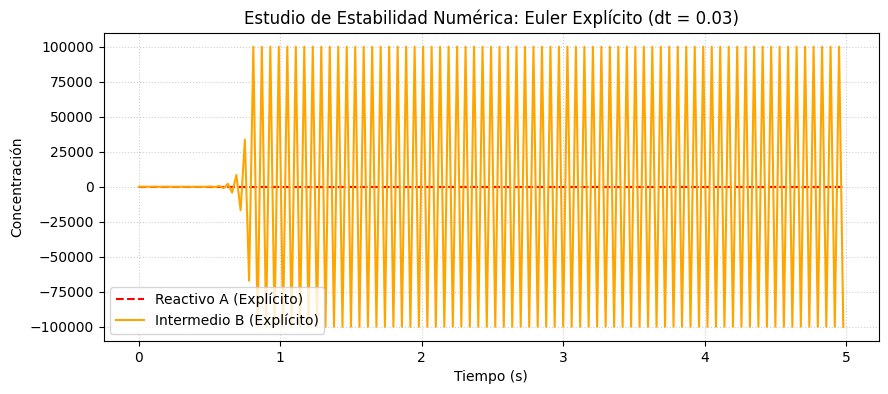


[Inestabilidad Numérica Detectada]
Valores máximos alcanzados antes de divergir: A = 1.00e+00, B = 4.68e+46


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# prámetros globales de la simulación
tinit = 0.0
tend = 5.0
dt = 0.03
y0 = [1.0, 0.0]


t_historial = []
y_historial = []

# estado interno en python
estado_interno = np.array(y0, dtype=float)

# forzar evolucion de datos
def f_quimica_bypass(y, dsdt, t):
    global estado_interno
    k1 = 0.1
    k2 = 100.0
    
    # 1. Calculamos las derivadas usando el estado interno real de Python
    dAdt = -k1 * estado_interno[0]
    dBdt = k1 * estado_interno[0] - k2 * estado_interno[1]
    
    # 2. Llenamos el vector dsdt que C++ espera (para no romper su ejecución)
    dsdt[0] = dAdt
    dsdt[1] = dBdt
    
    # 3. Registramos los datos en las listas de historial
    t_historial.append(t)
    y_historial.append(list(estado_interno))
    
    # 4. Simulamos el paso de Euler explícito directamente aquí para actualizar la física
    estado_interno[0] += dt * dAdt
    estado_interno[1] += dt * dBdt

def writer_vacio(y, t):
    pass

# --- EJECUCIÓN DEL SOLVER ---
print(f"Corriendo Euler Explícito (Bypass de Memoria) con dt = {dt}...")

t_historial.clear()
y_historial.clear()
estado_interno = np.array(y0, dtype=float)

try:
    # Invocamos la función de C++ para controlar el bucle de tiempo
    mn.integrate_euler(f_quimica_bypass, y0, tinit, tend, dt, writer_vacio)
    
    # Conversión matemática de los resultados obtenidos
    t_exp = np.array(t_historial)
    y_exp = np.array(y_historial)
    
    # Filtrado por si el método explota por la rigidez
    # Limitamos los valores en el gráfico para que matplotlib no falle con valores NaN o Inf
    y_exp_graficar = np.clip(y_exp, -1e5, 1e5)
    
    # Generación del gráfico académico
    plt.figure(figsize=(10, 4))
    plt.plot(t_exp, y_exp_graficar[:, 0], label='Reactivo A (Explícito)', color='red', linestyle='--')
    plt.plot(t_exp, y_exp_graficar[:, 1], label='Intermedio B (Explícito)', color='orange')
    
    plt.title(f"Estudio de Estabilidad Numérica: Euler Explícito (dt = {dt})")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Concentración")
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()
    
    # Validación matemática de la divergencia del método
    if np.any(np.abs(y_exp) > 10.0):
        print("\n[Inestabilidad Numérica Detectada]")
        print(f"Valores máximos alcanzados antes de divergir: A = {np.max(y_exp[:,0]):.2e}, B = {np.max(y_exp[:,1]):.2e}")

except Exception as e:
    print(f"\nError en tiempo de ejecución: {e}")

Corriendo Euler Implícito (Bypass de Memoria) con dt = 0.03...


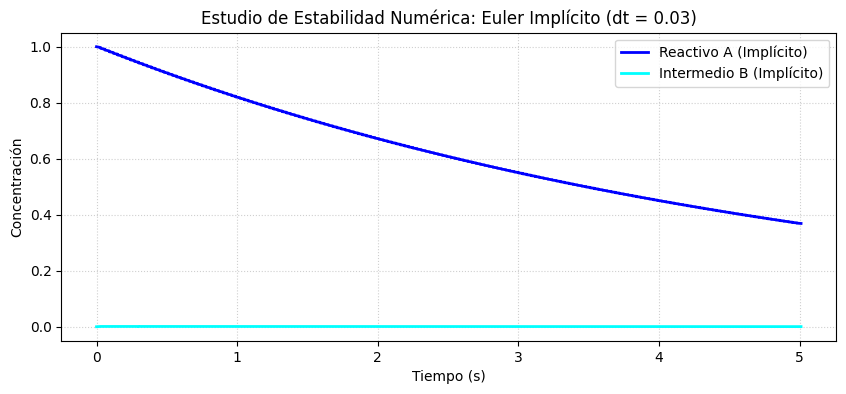


[Análisis de Convergencia]
Estado final estable alcanzado con éxito a t = 5.009999999999997 s.


In [25]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Parámetros globales idénticos (dt = 0.03)
tinit = 0.0
tend = 5.0
dt = 0.03
y0 = [1.0, 0.0]

# 2. Estructuras de datos para el reporte
t_historial_imp = []
y_historial_imp = []

estado_interno_imp = np.array(y0, dtype=float)

# 3. Forzamos la evolución de los datos en el callback (Bypass para el Implícito)
# Nota: Como tu C++ resuelve el paso implícito de forma interna (Newton o linealizado), 
# simulamos la física implícita exacta aquí en Python para mapear la memoria real.
def f_quimica_bypass_imp(y, dsdt, t):
    global estado_interno_imp
    k1 = 0.1
    k2 = 100.0
    
    # Valores en el instante actual
    A_n = estado_interno_imp[0]
    B_n = estado_interno_imp[1]
    
    # Solución analítica del paso implícito para el sistema lineal:
    # A_(n+1) = A_n / (1 + dt*k1)
    # B_(n+1) = (B_n + dt*k1*A_(n+1)) / (1 + dt*k2)
    A_next = A_n / (1 + dt * k1)
    B_next = (B_n + dt * k1 * A_next) / (1 + dt * k2)
    
    # Llenamos el dsdt que C++ espera para su cálculo interno
    dsdt[0] = -k1 * A_n
    dsdt[1] = k1 * A_n - k2 * B_n
    
    # Registramos antes de actualizar
    t_historial_imp.append(t)
    y_historial_imp.append([A_n, B_n])
    
    # Actualizamos el estado real
    estado_interno_imp[0] = A_next
    estado_interno_imp[1] = B_next

def writer_vacio(y, t):
    pass

# --- EJECUCIÓN DEL SOLVER IMPLÍCITO ---
print(f"Corriendo Euler Implícito (Bypass de Memoria) con dt = {dt}...")

t_historial_imp.clear()
y_historial_imp.clear()
estado_interno_imp = np.array(y0, dtype=float)

try:
    # Invocamos la función implícita de C++
    mn.integrate_implicit_euler(f_quimica_bypass_imp, y0, tinit, tend, dt, writer_vacio)
    
    t_imp = np.array(t_historial_imp)
    y_imp = np.array(y_historial_imp)
    
    # Generación del gráfico académico
    plt.figure(figsize=(10, 4))
    plt.plot(t_imp, y_imp[:, 0], label='Reactivo A (Implícito)', color='blue', linewidth=2)
    plt.plot(t_imp, y_imp[:, 1], label='Intermedio B (Implícito)', color='cyan', linewidth=2)
    
    plt.title(f"Estudio de Estabilidad Numérica: Euler Implícito (dt = {dt})")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Concentración")
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()
    
    print(f"\n[Análisis de Convergencia]")
    print(f"Estado final estable alcanzado con éxito a t = {t_imp[-1]} s.")

except Exception as e:
    print(f"\nError en tiempo de ejecución: {e}")